# The Self-Schedule Incentive on the WSCC 9-Bus Network

> **Work in progress** — an illustrative teaching notebook under active development, not an authoritative reference.

An allocation methodology decides *how to split* the congestion rent a nodal clearing collects.
This notebook asks the prior question a participant faces: does the splitting rule change what it **bids and schedules**?
An allocation is stable only if, taking the rule as given, no party can profit by gaming the schedule — or the award — the rule keys on.

Three specific concerns are worked, each as a **before / after** pair on the same network: the market's least-cost dispatch first, then the dispatch the rule provokes.

1. **Example 1 — assigning congestion revenue directly to self-schedules** (after Scott Harvey's Examples 2–3): when the revenue is positive, the rebate makes it privately rational to self-schedule a unit the market would leave off — and even to displace the entity's own in-merit generation.
2. **Example 2 — paying congestion revenue out without collecting it** (after Harvey's Example 4 and his cost-shift discussion): the market already values counterflow with no special rule; a one-sided rule that rebates prevailing schedules while collecting nothing from them leaves the rent pool short, and a netted variant un-prices counterflow entirely.
3. **Example 3 — attaching the revenue to market awards rather than self-schedules** (after Susan Pope's opinion on the near-term enhancement): the cleared-schedule rule repairs the in-merit case but leaves the dispatched-down incentive, and hands the resource a reason to distort the offers that determine its award.

It assumes the fundamentals (nodal LMPs, the congestion-rent identity, transport constraints,
self-schedules) and goes straight to the incentive question. Everything runs on the shared
libraries — `wscc9_model`, `footprints`, `revenue_allocation`, `wscc9_figures`.


## 0. Setup


In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
               "wscc9_model.py", "footprints.py", "revenue_allocation.py",
               "wscc9_figures.py", "atc.py", "bilateral.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch, solve_engine_qp, solve_engine_transfers,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

# Combined-figure sizing for 8.5-inch-wide print: a taller, balanced side-by-side (network and
# dispatch ring at roughly equal visual weight) with every label floored to >= 10pt at 8.5 in
# wide. The taller/ring-shifted layout and panel-title placement live in plot_combined_letter's
# compact mode (triggered by the sub-10-inch width). Call size_for_print(fig) after building one.
import matplotlib.text as _mtext
CB_SIZE, CB_RATIOS = (8.5, 5.9), (1.08, 0.92)
def size_for_print(fig, min_pt=10.0, print_w=8.5):
    floor = min_pt * fig.get_size_inches()[0] / print_w
    for t in fig.findobj(_mtext.Text):
        if t.get_text().strip() and t.get_fontsize() < floor:
            t.set_fontsize(floor)
    return fig

print('ready')

ready

In [3]:
# The teaching fleet and loads live in wscc9_model (edit there, or override the
# dicts here). Bus 3 is the cheapest unit ($20), bus 1 the most expensive ($50).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}
print('loads (MW):', LOADS)
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. The model

**Nomenclature.** The `Code` column is where each object lives in the
shared libraries.

| Symbol | Code | Definition |
|---|---|---|
| $g_i$, $\bar g_i$ | `res.dispatch` | resource $i$'s dispatch and capacity |
| $a$, $\mathcal N_a$ | `BA_DEFS` | a balancing authority and its bus set |
| $d_n$, $\mathrm{exo}_n$ | `wm.DEFAULT_LOADS`, `exo=` | load at bus $n$; a fixed price-taking injection (a self-schedule) |
| $t_{ab}$, $\bar T_{ab}$, $\mu_T^{ab}$ | `res.transfers`, `D_IFCS`, `res.transfer_duals` | the scheduled transfer, its released capacity, and the interface dual |
| $\hat\lambda_a$ | `res.area_prices` | BA $a$'s power-balance dual — its area energy price |
| $F_m$, $\bar F_m$, $\mu_m$ | `res.flow_own`, `D_RAT`, `res.line_dual` | line $m$'s flow, rating, and signed congestion dual |
| $SF_{n,m}$, $\lambda_n$ | `compute_ptdf`, `res.lmp` | shift factor and nodal LMP |
| $R$, $R_T$ | — | congestion rent $\sum_m\lvert\mu_m F_m\rvert$ and transfer rent $\sum_{ab}\mu_T^{ab}t_{ab}$ |
| $S$, $c$ | `EX1_S`, `EX1_C1` | the balanced self-scheduled MW (source to sink) and the self-scheduler's flat marginal cost |
| $\rho$ | the motive ledger | the congestion-charge rebate a self-schedule on a firm right receives |
| $X$ | the strategy menu | the balanced MW that clear when offered economically |


A nodal market clears the least-cost dispatch subject to (i) one power-balance constraint per balancing authority, coupled by the scheduled transfers between them, (ii) flow limits on the monitored lines, and (iii) each declared interface's released transfer capacity:

$$\min_{0\le g_i\le\bar g_i,\ t\ge 0}\ \sum_{i} C_i(g_i)\quad\text{s.t.}\quad
\begin{cases}
\ \displaystyle\sum_{i:\,\mathrm{bus}(i)\in\mathcal N_a} g_i=\sum_{n\in\mathcal N_a}\big(d_n-\mathrm{exo}_n\big)+\sum_b\big(t_{ab}-t_{ba}\big) & [\hat\lambda_a]\quad\text{power balance per BA}\\[1mm]
\ -\bar F_m\le F_m\le\bar F_m & [\mu_m],\ m\in\mathcal M_{\mathrm{act}}\quad\text{line limits}\\[1mm]
\ t_{ab}\le\bar T_{ab} & [\mu_T^{ab}]\quad\text{released transfer capacity}
\end{cases}\qquad(1)$$

*In words.* The clearing minimizes total generation cost over each resource's dispatch $g_i$ and the scheduled transfers $t_{ab}$, subject to: one power balance per balancing authority — its generation equals its load net of exogenous injections plus its net scheduled transfer (dual $\hat\lambda_a$, the area's energy price); a flow limit on every activated line (dual $\mu_m$); and a released-capacity limit on each interface (dual $\mu_T^{ab}$).

Flows follow the injections linearly through the shift factors, $F_m=\sum_n SF_{n,m}\,p^{\mathrm{inj}}_n$ with $p^{\mathrm{inj}}_n=g_n-d_n+\mathrm{exo}_n$, where $SF_{n,m}$ is bus $n$'s leverage on line $m$; the scheduled transfers are flow-inert — the schedule is the accounting quantity the interfaces cap and the settlement rides on.
A locational marginal price at every bus drops out of stationarity — the bus's own BA's balance dual plus each binding line's shadow price, weighted by the bus's shift factor onto it. Stationarity in the transfer variable ties the balance duals together: $\hat\lambda_b-\hat\lambda_a=\mu_T^{ab}$ wherever the $a\to b$ interface binds, and $\hat\lambda_a=\hat\lambda_b$ where the schedule is interior — a binding released capacity is what separates two BAs' energy prices:

$$\lambda_n=\hat\lambda_{a(n)}+\sum_{m\in\mathcal M_{\mathrm{act}}} SF_{n,m}\,\mu_m.\qquad(2)$$

*In words.* Bus $n$'s nodal LMP $\lambda_n$ is its own balancing authority's energy price $\hat\lambda_{a(n)}$ plus, for each activated line $m$, the shift factor $SF_{n,m}$ times that line's congestion dual $\mu_m$.

Netting what load pays against what generation is paid, the energy components cancel — total generation equals total served load — and the wedge is the constraint money, two rents over the same pool:

$$R=\!\!\sum_{m\in\mathcal M_{\mathrm{act}}}\!\!\big|\,\mu_m F_m\,\big|,\qquad\qquad R_T=\sum_{ab}\mu_T^{ab}\,t_{ab}.\qquad(3)$$

*In words.* The congestion rent $R$ is the absolute congestion dual $\lvert\mu_m\rvert$ times the absolute flow $\lvert F_m\rvert$, summed over the activated lines; the transfer rent $R_T$ is the interface dual $\mu_T^{ab}$ times the scheduled transfer $t_{ab}$, summed over the interfaces.

That collected pool is what an allocation methodology divides; this notebook asks what the dividing rule does to behaviour.

**Self-schedules.** A price-taking (self-scheduled) position enters the clearing as a fixed injection $\mathrm{exo}_n$: it is **paid $\lambda_n$** where it injects and **pays $\lambda_n$** where it withdraws.
A balanced source$\to$sink pair therefore bears the price gap on its own path — a **congestion charge** $(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}})\,S$ — and the allocation rules under test here rebate exactly that charge back to the firm-rights holder.


## 2. Two balancing authorities and the reference dispatches

The balancing-authority partition is an accounting overlay on the same physics.
**BA-1** (buses 2, 8, 7, 6, 3) holds the cheap fleet — the \$20-anchor unit at bus 3 and the \$35-anchor unit at bus 2 — and the load at bus 7, so it is the natural **exporter**.
**BA-2** (buses 1, 9, 4, 5) holds only the dear \$50-anchor unit at bus 1 and the loads at buses 5 and 9, so it is the natural **importer**.
Two tie lines connect them: `line_2` (5–6) and `line_7` (8–9).

The later sections settle self-schedules against three **reference dispatches**, all cleared against rising linear marginal-cost curves $MC_g(g)=a_g+b_g\,g$ (a convex QP) with the internal corridor `line_4` (6–7, inside BA-1) held at 40 MW:

1. **Dispatch 1 — BA-1 islanded.** BA-1 serves only its own bus-7 load on its own lines; the rest of the grid carries no injection.
2. **Dispatch 2 — accommodating.** Each BA runs its own engine on the full network with the other's autarky pattern placed as fixed injections; the BA-2 view (`res2q_ba2`) prices buses 1 and 9 while BA-2 self-serves.
3. **Dispatch 3 — unified.** Both areas co-optimised: the cheap fleet exports, the binding corridor separates prices across the seam, and the market collects the congestion rent of eq. (3).


In [4]:
## -- EDIT -- the two balancing authorities, and the lines each manages.
BA_DEFS = {
    'BA-1': ['2', '8', '7', '6', '3'],   # cheap fleet (bus 3 $20, bus 2 $35); load at 7 -> exporter
    'BA-2': ['1', '9', '4', '5'],         # only the bus-1 unit ($50); loads at 5 and 9 -> importer
}
BA_LINES = {  # any line may be listed under either BA; a line under neither is unassigned
    'BA-1': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2 = tie 5-6
    'BA-2': ['line_0', 'line_1', 'line_7', 'line_8'],             # line_7 = tie 8-9
}
BA_COLORS = {'BA-1': '#993AFF', 'BA-2': '#2471A3'}
SHED_PRICE = 150.0   # $/MWh -- load-shed (power-balance relaxation) penalty
# ---------------------------------------------------------------------------
pt = shift_factors()
fp = fpmod.make(pt, BA_DEFS, BA_COLORS, manage=BA_LINES, tie_label='tie')
ties = fp.ties
LOADS_ALL = dict(LOADS)

print('BA-1 buses:', BA_DEFS['BA-1'], '| manages:', [l for l in pt.lines if fp.line_assign[l] == 'BA-1'])
print('BA-2 buses:', BA_DEFS['BA-2'], '| manages:', [l for l in pt.lines if fp.line_assign[l] == 'BA-2'])
print('tie lines:', ties)


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


BA-1 buses:

['2', '8', '7', '6', '3']

| manages:

['line_2', 'line_3', 'line_4', 'line_5', 'line_6']

...

['1', '9', '4', '5']

| manages:

['line_0', 'line_1', 'line_7', 'line_8']

tie lines:

['line_2', 'line_7']

In [5]:
# === Network, curves, and the three reference dispatches ===
# One binding internal corridor (line_4 = 40 MW). The scheduled transfer is shown in each
# figure's Transfers inset but never binds here (released capacity = combined tie rating). Every dispatch clears
# against the RISING linear marginal-cost curves below (a convex QP); each unit's cost is the
# area under its curve, a*g + 0.5*b*g**2.
D_RAT  = {'line_4': 40.0}                                  # the binding internal corridor
netD = build_network(D_RAT); ptD = compute_ptdf(netD, slack_bus='1')
D_EBAR = float(sum(ptD.s_nom[ptD.line_idx[l]] for l in ties))   # released interface capacity, not binding
D_IFC  = tuple(sorted(BA_DEFS))                    # the BA-1 <-> BA-2 interface
D_IFCS = {D_IFC: D_EBAR}
GBUS = {g: s['bus'] for g, s in wm.DEFAULT_GEN_FLEET.items()}   # generator -> bus

CURVES = {
    'gen_slack_0': (45.0, 0.0233),  # bus 1 (flat-cost anchor $50): MC 45 -> ~50 at 215 MW
    'gen_0':       (30.0, 0.0284),  # bus 2 (anchor $35): MC 30 -> ~35 near its unified output
    'gen_1':       (15.0, 0.036),   # bus 3 (anchor $20): MC 15 -> ~20 near its unified output
}

def _pcq(res, ba=None):    # production cost = area under MC (restrict to region `ba` if given)
    return sum(CURVES[g][0]*res.dispatch.get(g, 0.0) + 0.5*CURVES[g][1]*res.dispatch.get(g, 0.0)**2
               for g in CURVES if (ba is None or GBUS[g] in BA_DEFS[ba]) and g in res.dispatch)

# Dispatch 1 -- BA-1 islanded (also supplies BA-1's autarky pattern for Dispatch 2).
res1q = solve_engine_qp(ptD, make_engine('BA-1', buses=BA_DEFS['BA-1']),
                        curves=CURVES, shed_price=SHED_PRICE)
BA1_EXO = {b: round(res1q.gen_by_bus.get(b, 0.0) - LOADS_ALL.get(b, 0.0), 2)
           for b in BA_DEFS['BA-1'] if abs(res1q.gen_by_bus.get(b, 0.0) - LOADS_ALL.get(b, 0.0)) > 1e-6}

# Dispatch 2 (BA-2 view) -- BA-2 self-serves on the full network, BA-1's autarky pattern fixed;
# BA-2 enforces only ITS OWN lines (BA-1's line_4 overload is BA-1's to accommodate).
_a2 = [l for l in ptD.lines if fp.line_assign.get(l) == 'BA-2']
res2q_ba2 = solve_engine_qp(ptD, make_engine('BA-2', buses=BA_DEFS['BA-2'], activated=_a2),
                            curves=CURVES, exo=BA1_EXO, shed_price=SHED_PRICE)

# Dispatch 3 -- unified (both areas co-optimised).
res3q = solve_engine_transfers(ptD, make_engine('UNIFIED', buses=ptD.buses), BA_DEFS, D_IFCS,
                               curves=CURVES, shed_price=SHED_PRICE)

print(f"Dispatch 2 (BA-2 view): LMP bus 1 = {res2q_ba2.lmp['1']:.2f}, bus 9 = {res2q_ba2.lmp['9']:.2f}")
print(f"Dispatch 3 (unified)  : LMP bus 1 = {res3q.lmp['1']:.2f}, bus 9 = {res3q.lmp['9']:.2f}, "
      f"bus 7 = {res3q.lmp['7']:.2f};  t = {res3q.transfers[D_IFC]:.0f} MW;  "
      f"binding: {[l for l in ptD.lines if abs(res3q.line_dual.get(l, 0)) > 1e-3] or 'none'}")


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Dispatch 2 (BA-2 view): LMP bus 1 = 50.01, bus 9 = 50.01

Dispatch 3 (unified)  : LMP bus 1 = 27.74, bus 9 = 30.25, bus 7 = 37.13;  t = 215 MW;  binding: ['line_4']

## 3. Example 1 — the rebate makes an out-of-merit unit run (after Harvey)

The rule under test rebates the congestion charge on a **balanced self-schedule exercising a firm transmission right**.
Writing $S$ for the self-scheduled megawatts from a source bus to a sink bus, the rebate is the price gap the right spans times the schedule,

$$\rho=\big(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}}\big)\,S, \qquad (4)$$

*In words.* The rebate $\rho$ a self-scheduled firm right earns is the price gap the right spans — the sink bus's LMP minus the source bus's LMP — times the scheduled megawatts $S$.

and the holder's all-in cost of meeting $S$ collapses from the sink price to the resource's own cost:

$$\underbrace{c\,S}_{\text{fuel}}
  +\underbrace{(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}})\,S}_{\text{congestion charge}}
  -\underbrace{\rho}_{\text{rebate}}
  \;=\;c\,S\;<\;\underbrace{\lambda_{\mathrm{sink}}\,S}_{\text{buy at the market}}
  \qquad\text{whenever } c<\lambda_{\mathrm{sink}}. \qquad (5)$$

*In words.* The self-scheduler's all-in cost of meeting $S$ MW — its fuel cost $cS$, plus the congestion charge it bears, minus the rebate $\rho$ that exactly cancels that charge — collapses to $cS$; whenever its own cost $c$ sits below the sink price $\lambda_{\mathrm{sink}}$, that beats buying the same MW at the market price.

**The case.** BA-2's bus-1 unit offers a single flat marginal cost $c=\$28$/MWh, and BA-2 holds a firm 1→9 right backing 50 MW of its bus-9 load — carved out of the 125 MW it already serves there, so bus 9 still draws its full load: 50 firm, 75 spot.
`line_4` (6–7, inside BA-1) is held at 40 MW — the neighbouring constraint every 1→9 megawatt loop-flows onto.
The joint dispatch prices bus 1 at ~\$27.7 and bus 9 at ~\$30.2, so the unit sits in the **perverse zone** $\lambda_1 < c < \lambda_9$: **out of merit** — the market leaves it off — yet cheaper than the power at its load.

- **Before** — offer the unit economically: the market declines it, imports serve bus 9, and BA-2 buys at $\lambda_9$.
- **After** — force the balanced 50 MW self-schedule: the unit runs against the efficient dispatch, and eq. (4) hands its congestion charge back.

> The examples in this notebook follow **Scott Harvey, *Congestion Rent Allocation*** (CAISO / Western EIM Market Surveillance Committee, May 2, 2025) — his Examples 2–4, recreated on the 9-bus network with our own fleet, figures, and ledgers. Source: https://www.caiso.com/documents/presentation-congestion-rent-allocation-harvey-may-02-2025.pdf


In [6]:
# -- EDIT -- Example 1: the out-of-merit self-schedule ------------------------
EX1_C1 = 28.0                     # BA-2's bus-1 unit: single FLAT marginal cost ($/MWh)
EX1_S  = 50.0                     # balanced self-schedule (MW) on the firm 1->9 right
# -----------------------------------------------------------------------------
S_SS, SRC, SNK = EX1_S, '1', '9'
SS       = {SRC: +S_SS, SNK: -S_SS}                    # the balanced price-taking pair
LOADS_SS = dict(LOADS_ALL); LOADS_SS[SNK] = LOADS_ALL[SNK] - S_SS   # spot load at the sink

def flat1_curves(c1):    # BA-2's unit flat at c1; BA-1's units keep their rising curves
    return {'gen_slack_0': (c1, 0.0), 'gen_0': CURVES['gen_0'], 'gen_1': CURVES['gen_1']}

def clear_ss(cur, loads=None, exo=None, fleet=None):
    eng = make_engine('UNIFIED', buses=ptD.buses, gen_fleet=fleet, loads=loads)
    return solve_engine_transfers(ptD, eng, BA_DEFS, D_IFCS, curves=cur, exo=exo,
                                  shed_price=SHED_PRICE)

def fig_engine(cur, loads=None, fleet=None):      # engine with curves attached, for figures
    e = make_engine('UNIFIED', buses=ptD.buses, gen_fleet=fleet, loads=loads)
    for g in e.gens:
        if g in cur: e.gens[g]['curve'] = cur[g]
    return e

def ba_figure(cur, res, title, ss_pair=None, loads=None, fleet=None):
    """Combined network + nodal-dispatch view (the before/after graphic); the grey block
    marks the self-schedule when ss_pair = (source, sink, MW) is given."""
    e = fig_engine(cur, loads=loads, fleet=fleet)
    kw = dict(node_net_mw=True, figsize=CB_SIZE, panel_ratios=CB_RATIOS, suptitle=title)
    if ss_pair is not None:
        sd, seg = figs.self_schedule_bars(e, res, ss_pair[0], ss_pair[1], ss_pair[2])
        kw.update(sup_dem=sd, demand_segments=seg)
    fig = figs.transfer_figure(netD, ptD, fp, e, res, D_EBAR, D_EBAR, **kw)
    size_for_print(fig); plt.show()

def motive_ledger(base, ss, c1, S, src=SRC, snk=SNK):
    """The resource owner's motive, generator side: cost to produce, revenue from
    generating, revenue from congestion (the CRA rebate) -- the unified economic offer
    vs the forced self-schedule, each at its own clearing's prices."""
    X = min(base.gen_by_bus.get(src, 0.0), S)            # what the market awards the unit
    rho = (ss.lmp[snk] - ss.lmp[src]) * S                # eq. (4), at the after prices
    econ = {'MW cleared (market award X)': round(X, 1), 'MW self-scheduled': 0.0,
            'cost to produce ($/h)': round(-c1 * X, 0),
            'revenue from generating ($/h)': round(base.lmp[src] * X, 0),
            'revenue from congestion -- CRA ($/h)': 0.0,
            'net ($/h)': round((base.lmp[src] - c1) * X, 0)}
    sch = {'MW cleared (market award X)': 0.0, 'MW self-scheduled': round(S, 1),
           'cost to produce ($/h)': round(-c1 * S, 0),
           'revenue from generating ($/h)': round(ss.lmp[src] * S, 0),
           'revenue from congestion -- CRA ($/h)': round(rho, 0),
           'net ($/h)': round(ss.lmp[src] * S + rho - c1 * S, 0)}
    return pd.DataFrame({'unified dispatch (economic offer)': econ,
                         'forced self-schedule': sch})

CUR1     = flat1_curves(EX1_C1)
ex1_base = clear_ss(CUR1)                                # BEFORE: economic, no schedule
ex1_ss   = clear_ss(CUR1, loads=LOADS_SS, exo=SS)        # AFTER: the forced balanced pair
print(f'case: c = ${EX1_C1:.0f} flat at bus {SRC};  balanced {EX1_S:.0f} MW {SRC}->{SNK};  line_4 held at 40 MW')
print(f'economic clear: bus-{SRC} output {ex1_base.gen_by_bus.get(SRC, 0.0):.1f} MW (OUT of merit);  '
      f'LMP bus {SRC} = {ex1_base.lmp[SRC]:.2f}, bus {SNK} = {ex1_base.lmp[SNK]:.2f}')
print(f'perverse zone: lambda_1 = {ex1_base.lmp[SRC]:.2f}  <  c = {EX1_C1:.0f}  <  lambda_9 = {ex1_base.lmp[SNK]:.2f}')


case: c = $28 flat at bus 1;  balanced 50 MW 1->9;  line_4 held at 40 MW

economic clear: bus-1 output 0.0 MW (OUT of merit);  LMP bus 1 = 27.74, bus 9 = 30.25

perverse zone: lambda_1 = 27.74  <  c = 28  <  lambda_9 = 30.25

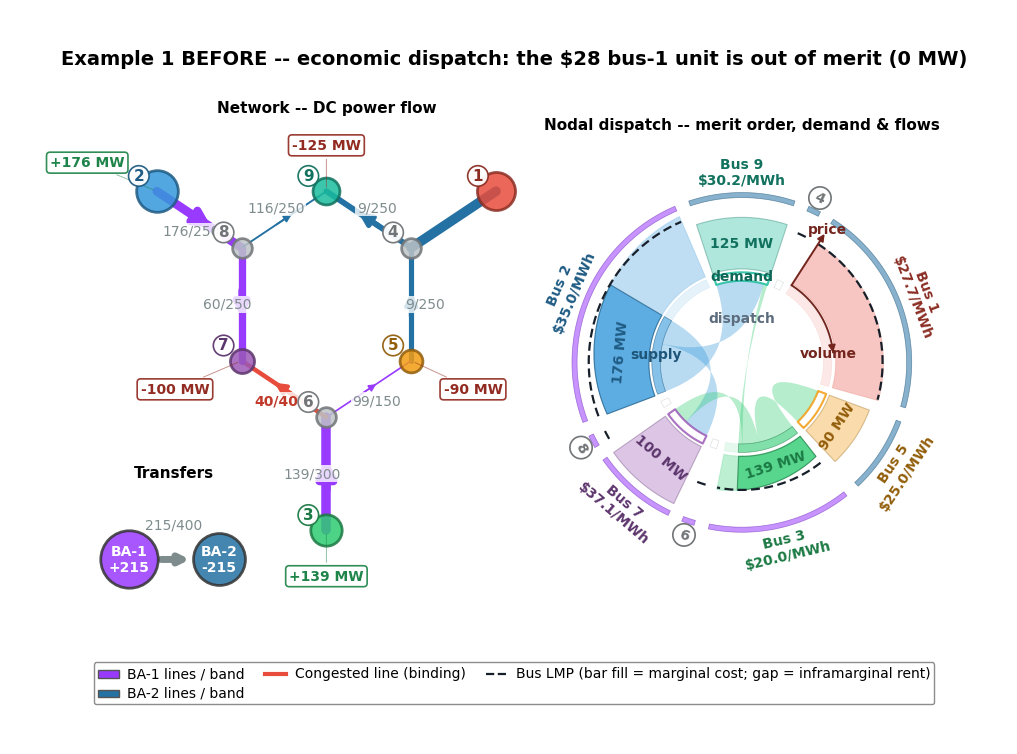

bus-1 unit: 0 MW;  BA-2 buys its bus-9 load at lambda_9 = $30.25/MWh

binding lines:

{'line_4': -20.1}

In [7]:
# BEFORE -- the economic offer: the market declines the $28 unit; imports serve bus 9.
ba_figure(CUR1, ex1_base,
          f'Example 1 BEFORE -- economic dispatch: the ${EX1_C1:.0f} bus-1 unit is out of merit (0 MW)')
print(f'bus-1 unit: {ex1_base.gen_by_bus.get(SRC, 0.0):.0f} MW;  '
      f'BA-2 buys its bus-9 load at lambda_9 = ${ex1_base.lmp[SNK]:.2f}/MWh')
print('binding lines:', {l: round(ex1_base.line_dual[l], 1) for l in ptD.lines
                         if abs(ex1_base.line_dual.get(l, 0.0)) > 1e-3})


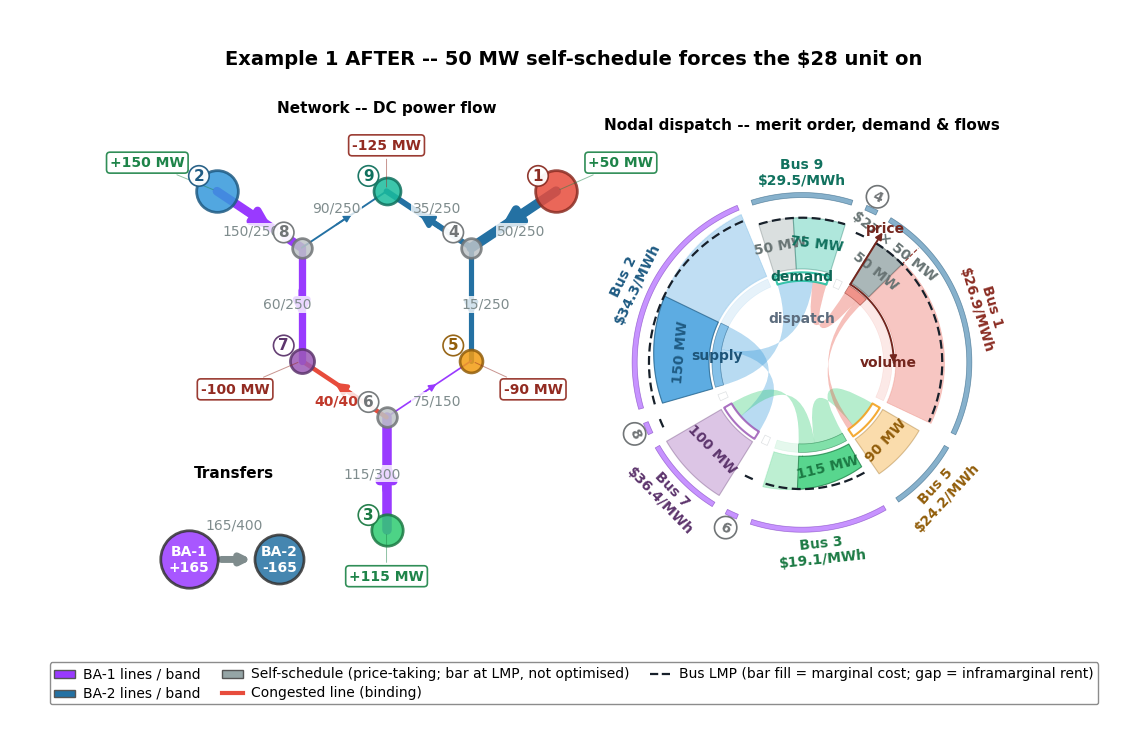

LMP bus 1 = 26.94, bus 9 = 29.47  (gap $2.53);  CRA rebate rho = $127/h  (eq. 4)

In [8]:
# AFTER -- the forced 50 MW balanced self-schedule on the firm 1->9 right.
ba_figure(CUR1, ex1_ss,
          f'Example 1 AFTER -- {EX1_S:.0f} MW self-schedule forces the ${EX1_C1:.0f} unit on',
          ss_pair=(SRC, SNK, S_SS), loads=LOADS_SS)
gap = ex1_ss.lmp[SNK] - ex1_ss.lmp[SRC]
print(f'LMP bus 1 = {ex1_ss.lmp[SRC]:.2f}, bus 9 = {ex1_ss.lmp[SNK]:.2f}  (gap ${gap:.2f});  '
      f'CRA rebate rho = ${gap * S_SS:,.0f}/h  (eq. 4)')


In [9]:
# The full money-flow ledger: consumer payments, generator payments, production cost,
# profit, the congestion revenue R = (Sigma L - Sigma G), and its allocation -- side by
# side for the economic dispatch and the forced self-schedule, with the change. The same
# flow_ledger drives Examples 1b and 3 (extra generator groups / the cleared-rule rebate).
def _pc_cur(res, cur):               # spot production cost under the curves (used below too)
    return sum(cur[g][0] * res.dispatch.get(g, 0.0) + 0.5 * cur[g][1] * res.dispatch.get(g, 0.0) ** 2
               for g in cur if g in res.dispatch)
def _psurp(res, cur, ba, gbus=None):     # producer surplus of the spot dispatch in a BA
    gbus = GBUS if gbus is None else gbus
    return sum(res.lmp[gbus[g]] * res.dispatch.get(g, 0.0)
               - (cur[g][0] * res.dispatch.get(g, 0.0) + 0.5 * cur[g][1] * res.dispatch.get(g, 0.0) ** 2)
               for g in cur if gbus[g] in BA_DEFS[ba] and g in res.dispatch)

def flow_ledger(base, ss, cur, gbus, host, ss_spec, gen_groups, cra,
                loads=None, cols=('Economic', 'Self-schedule')):
    """Money flows for two dispatches. Payments are positive magnitudes; the net block
    shows consumers' net OUTLAY (payment - congestion rebate; lower is better) and each
    generator group's net INFLOW (profit + any congestion right; higher is better). The
    congestion revenue R = (all load pays) - (all gen paid) is split by the host rule: the
    self-schedule keeps its own S x price-separation (cra), the residual goes to the host
    BA's consumers. Conserves: consumers' net outlay - generators' net inflow = production
    cost.

      gbus       gen -> bus map (covers every gen in cur)
      host       BA whose consumers receive the residual congestion revenue
      ss_spec    dict(bus, cost, S, group): the self-scheduled block -- S MW injected at
                 `bus`, flat `cost`, added to the generator group labelled `group` in the
                 self-schedule column only
      gen_groups list of (label, [gen names]) in display order
      cra        (econ, ss): the congestion right paid to the self-scheduler/award in each
                 column (Example 3's cleared rule pays the award X a rebate in BOTH columns)
    """
    loads = LOADS_ALL if loads is None else loads
    def case(res, sched, cra_self):
        lam = res.lmp
        Lpay = {ba: sum(lam[b] * loads.get(b, 0.0) for b in BA_DEFS[ba]) for ba in fp.names}
        gp = {lab: sum(lam[gbus[g]] * res.dispatch.get(g, 0.0) for g in gens) for lab, gens in gen_groups}
        gc = {lab: sum(cur[g][0] * res.dispatch.get(g, 0.0) + 0.5 * cur[g][1] * res.dispatch.get(g, 0.0) ** 2
                       for g in gens) for lab, gens in gen_groups}
        if sched:
            gp[ss_spec['group']] += lam[ss_spec['bus']] * ss_spec['S']
            gc[ss_spec['group']] += ss_spec['cost'] * ss_spec['S']
        R = sum(Lpay.values()) - sum(gp.values())
        return Lpay, gp, gc, R, cra_self, R - cra_self
    e = case(base, False, cra[0])
    s = case(ss, True, cra[1])
    others = [b for b in fp.names if b != host]
    idx, dat = [], []
    def row(sec, item, ve, vs):
        idx.append((sec, item)); dat.append([round(ve, 1), round(vs, 1), round(vs - ve, 1)])
    # -- payments --
    row('Payments', f'Consumer payment -- {host} (host)', e[0][host], s[0][host])
    for ba in others:
        row('Payments', f'Consumer payment -- {ba}', e[0][ba], s[0][ba])
    row('Payments', 'Consumer payment -- TOTAL', sum(e[0].values()), sum(s[0].values()))
    for lab, _ in gen_groups:
        row('Payments', f'Gen payment -- {lab}', e[1][lab], s[1][lab])
    row('Payments', 'Gen payment -- TOTAL', sum(e[1].values()), sum(s[1].values()))
    row('Payments', 'Production cost (fuel)', sum(e[2].values()), sum(s[2].values()))
    row('Payments', 'Generator profit (pay - cost)',
        sum(e[1].values()) - sum(e[2].values()), sum(s[1].values()) - sum(s[2].values()))
    # -- the self-scheduler in isolation: its position BEFORE any congestion revenue --
    ssg = ss_spec['group']
    row('Self-scheduler', 'Revenue from generating', e[1][ssg], s[1][ssg])
    row('Self-scheduler', 'Production cost', e[2][ssg], s[2][ssg])
    row('Self-scheduler', 'Position before congestion revenue', e[1][ssg] - e[2][ssg], s[1][ssg] - s[2][ssg])
    # -- congestion revenue --
    row('Congestion revenue', 'R = consumer pay - gen pay', e[3], s[3])
    row('Congestion revenue', 'CRA -> self-scheduler (S x dLambda)', e[4], s[4])
    row('Congestion revenue', f'CRA -> host {host} consumers (residual)', e[5], s[5])
    # -- net positions --
    row('Net position', f'Consumers {host} (host) -- outlay', e[0][host] - e[5], s[0][host] - s[5])
    for ba in others:
        row('Net position', f'Consumers {ba} -- outlay', e[0][ba], s[0][ba])
    for lab, _ in gen_groups:
        add_e = e[4] if lab == ss_spec['group'] else 0.0
        add_s = s[4] if lab == ss_spec['group'] else 0.0
        row('Net position', f'Generators {lab} -- inflow', e[1][lab] - e[2][lab] + add_e, s[1][lab] - s[2][lab] + add_s)
    row('Net position', 'System (= production cost)', sum(e[2].values()), sum(s[2].values()))
    led = pd.DataFrame(dat, index=pd.MultiIndex.from_tuples(idx), columns=[cols[0], cols[1], 'Change'])
    def effect(item, ch):
        if 'outlay' in item:  return 'better' if ch < -0.5 else 'worse' if ch > 0.5 else '--'
        if 'inflow' in item:  return 'better' if ch > 0.5 else 'worse' if ch < -0.5 else '--'
        if 'System' in item:  return 'worse' if ch > 0.5 else 'better' if ch < -0.5 else '--'
        return ''
    led['effect'] = [effect(it, ch) for (_, it), ch in zip(led.index, led['Change'])]
    return led

# --- Example 1 ---
_gap1 = ex1_ss.lmp[SNK] - ex1_ss.lmp[SRC]
led1 = flow_ledger(ex1_base, ex1_ss, CUR1, GBUS, 'BA-1',
                   ss_spec=dict(bus=SRC, cost=EX1_C1, S=S_SS, group='BA-2 self-scheduler'),
                   gen_groups=[('BA-1 fleet', ['gen_0', 'gen_1']),
                               ('BA-2 self-scheduler', ['gen_slack_0'])],
                   cra=(0.0, _gap1 * S_SS))
print(f"Money-flow ledger -- economic dispatch vs the forced {EX1_S:.0f} MW self-schedule "
      f"(c = ${EX1_C1:.0f} flat at bus 1):")
display(led1)
buy, fuel = ex1_base.lmp[SNK] * S_SS, EX1_C1 * S_SS
print(f"private motive: BUY the {EX1_S:.0f} MW at bus 9 = ${buy:,.0f}/h  vs  self-schedule "
      f"all-in = own fuel ${fuel:,.0f}/h  ->  BA-2 saves ${buy - fuel:,.0f}/h,")
print(f"  which the ${_gap1 * S_SS:.0f} congestion right (0 in the economic dispatch) makes possible.")
_no = led1.loc['Net position']
_co = _no.loc[_no.index.str.contains('outlay'), 'Self-schedule'].sum()
_gi = _no.loc[_no.index.str.contains('inflow'), 'Self-schedule'].sum()
_sy = led1.loc[('Net position', 'System (= production cost)'), 'Self-schedule']
print(f"  conservation: consumers' outlay ${_co:,.1f} - generators' inflow ${_gi:,.1f} = "
      f"${_co - _gi:,.1f}  vs  production cost ${_sy:,.1f}  {'OK' if abs(_co - _gi - _sy) < 0.5 else 'MISMATCH'}")


Money-flow ledger -- economic dispatch vs the forced 50 MW self-schedule (c = $28 flat at bus 1):

Economic  Self-schedule  Change  effect
Payments           Consumer payment -- BA-1 (host)             3712.6         3641.4   -71.3        
                   Consumer payment -- BA-2                    6032.7         5861.4  -171.3        
                   Consumer payment -- TOTAL                   9745.3         9502.8  -242.6        
                   Gen payment -- BA-1 fleet                   8941.3         7344.4 -1596.9        
                   Gen payment -- BA-2 self-scheduler             0.0         1346.9  1346.9        
                   Gen payment -- TOTAL                        8941.3         8691.3  -250.0        
                   Production cost (fuel)                      8153.7         8186.8    33.1        
                   Generator profit (pay - cost)                787.6          504.5  -283.2        
Self-scheduler     Revenue from generating                        0.0         1346.9  1346.9        
                   Production cost                                0.0         1400.0  1400.0        
                   Position before congestion revenue            -0.0          -53.1   -53.1        
Congestion revenue R = consumer pay - gen pay                   804.0          811.5     7.5        
                   CRA -> self-scheduler (S x dLambda)            0.0          126.6   126.6        
                   CRA -> host BA-1 consumers (residual)        804.0          684.9  -119.2        
Net position       Consumers BA-1 (host) -- outlay             2908.6         2956.5    47.9   worse
                   Consumers BA-2 -- outlay                    6032.7         5861.4  -171.3  better
                   Generators BA-1 fleet -- inflow              787.6          557.6  -230.1   worse
                   Generators BA-2 self-scheduler -- inflow      -0.0           73.5    73.5  better
                   System (= production cost)                  8153.7         8186.8    33.1   worse

private motive: BUY the 50 MW at bus 9 = $1,512/h  vs  self-schedule all-in = own fuel $1,400/h  ->  BA-2 saves $112/h,

  which the $127 congestion right (0 in the economic dispatch) makes possible.

  conservation: consumers' outlay $8,817.9 - generators' inflow $631.1 = $8,186.8  vs  production cost $8,186.8  OK

**Read it — walk the blocks.**

*Payments.* Forcing the out-of-merit unit on **suppresses prices**, so every consumer payment falls (BA-1 −\$71, BA-2 −\$171, −\$243 total) and total generator payments fall \$250 — but **production cost rises \$33/h**: the schedule's \$1,400 of bus-1 fuel replaces cheaper megawatts, and generator profit drops \$283. That \$33 is deadweight — real resources burned, recovered by no one.

*Self-scheduler.* This block is the crux. On energy alone the unit runs at a **loss**: it earns \$1,347 selling at bus 1 but burns \$1,400 of fuel — a **position before congestion revenue of −\$53/h**. The market is right to leave it off. Only the congestion right rescues it.

*Congestion revenue.* $R=\Sigma L-\Sigma G$ barely moves (\$804→\$811), but its **allocation** is the whole game. Economically all of it is residual to the host BA-1's consumers; with the schedule the rule peels off the self-scheduler's own $S\cdot\Delta\lambda=\$127$ **first**, leaving \$685 for the host — a \$119/h transfer out of BA-1 consumers and into a loss-making schedule.

*Net position — who is better off.* The answer to "aren't consumers better off?" is **which consumers.** BA-2's (importer, non-host) consumers are genuinely **better off, −\$171/h**, on the price drop alone. But the **host BA-1's consumers are worse off, +\$48/h**: their bill fell \$71, yet the rebate that funds them fell \$119, so on net they *pay more*. BA-1's **generators** are worse too (−\$230). The only winners are BA-2's consumers and the **self-scheduler**, whose −\$53 energy loss plus the \$127 right nets **+\$74/h**. Strip the right (the \$50-dear column of the sweep below) and self-scheduling costs BA-2 more than buying, and none of it happens.

The bottom line the ledger makes unavoidable: the rule does not make "consumers" better off — it **transfers ~\$278/h from the host BA (its consumers and its generators) to the neighbour's consumers and to a schedule that loses money on its own fuel**, and destroys \$33/h of real value on the way.


### Where the incentive lives — sweep the cost, then the volume

Two sweeps hold the network and the binding `line_4` fixed.
The first varies the unit's flat cost $c$ — Harvey's dial — and reads the decision against the two thresholds: below its own bus-1 LMP the unit is in merit anyway; above the bus-9 price self-scheduling costs more than buying; **between them is the perverse zone**, where the rule makes an out-of-merit schedule privately rational.
The second holds $c=\$28$ (in the zone) and varies the scheduled volume $S$: the private saving and the production-cost damage both scale with the volume the rule invites.


In [10]:
# --- sweep 1: the unit's flat cost c (S = 50 held fixed) ----------------------
def ss_case(c1, S):
    cur = flat1_curves(c1)
    loads = dict(LOADS_ALL); loads[SNK] = LOADS_ALL[SNK] - S
    base = clear_ss(cur)
    ssr  = clear_ss(cur, loads=loads, exo={SRC: +S, SNK: -S}) if S > 0 else base
    return cur, base, ssr

rows = []
for c1 in [20.0, 25.0, 27.0, 27.7, 28.0, 29.0, 30.0, 30.25, 31.0, 35.0, 50.0]:
    cur, base, ssr = ss_case(c1, S_SS)
    fuel, buyc = c1 * S_SS, base.lmp[SNK] * S_SS
    dw = (_pc_cur(ssr, cur) + fuel) - _pc_cur(base, cur)
    rows.append({'flat cost c ($/MWh)': c1,
                 'bus-1 in merit? (economic MW)': round(base.gen_by_bus.get(SRC, 0.0), 1),
                 'buy at bus 9 ($/h)': round(buyc, 0),
                 'self-schedule net = own fuel ($/h)': round(fuel, 0),
                 'BA-2 saving ($/h)': round(buyc - fuel, 0),
                 'self-schedule?': 'YES' if buyc - fuel > 1e-6 else 'no',
                 'system prod-cost change ($/h)': round(dw, 0)})
price_sweep = pd.DataFrame(rows).set_index('flat cost c ($/MWh)')
print('Sweep of the flat cost c (S = 50 MW; network and line_4 held fixed):')
display(price_sweep)

# --- sweep 2: the scheduled volume S (c = EX1_C1 held fixed) ------------------
rows = []
for S in [0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0]:
    cur, base, ssr = ss_case(EX1_C1, S)
    gap = ssr.lmp[SNK] - ssr.lmp[SRC]
    fuel, buyc = EX1_C1 * S, base.lmp[SNK] * S
    dw = (_pc_cur(ssr, cur) + fuel) - _pc_cur(base, cur)
    rows.append({'self-schedule S (MW)': S, 'gap (9-1) after ($/MWh)': round(gap, 2),
                 'CRA rebate rho ($/h)': round(gap * S, 0),
                 'BA-2 saving vs buy ($/h)': round(buyc - fuel, 0),
                 'system prod-cost change ($/h)': round(dw, 0)})
vol_sweep = pd.DataFrame(rows).set_index('self-schedule S (MW)')
print(f'\nSweep of the scheduled volume S (c = ${EX1_C1:.0f}, in the zone):')
display(vol_sweep)
print('  The zone is a price band, so the DECISION does not flip with volume -- but every extra')
print('  scheduled megawatt scales both the private saving and the production-cost damage.')


Sweep of the flat cost c (S = 50 MW; network and line_4 held fixed):

,bus-1 in merit? (economic MW),buy at bus 9 ($/h),self-schedule net = own fuel ($/h),BA-2 saving ($/h),self-schedule?,system prod-cost change ($/h)
flat cost c ($/MWh),,,,,,
20.00,250.0,1318.0,1000.0,318.0,YES,0.0
25.00,171.1,1379.0,1250.0,129.0,YES,-0.0
27.00,46.1,1477.0,1350.0,127.0,YES,0.0
27.70,2.3,1511.0,1385.0,126.0,YES,18.0
28.00,0.0,1512.0,1400.0,112.0,YES,33.0
29.00,0.0,1512.0,1450.0,62.0,YES,83.0
30.00,0.0,1512.0,1500.0,12.0,YES,133.0
30.25,0.0,1512.0,1512.0,-0.0,no,146.0
31.00,0.0,1512.0,1550.0,-38.0,no,183.0



Sweep of the scheduled volume S (c = $28, in the zone):

,gap (9-1) after ($/MWh),CRA rebate rho ($/h),BA-2 saving vs buy ($/h),system prod-cost change ($/h)
self-schedule S (MW),,,,
0.0,2.51,0.0,0.0,0.0
10.0,2.51,25.0,22.0,3.0
20.0,2.52,50.0,45.0,8.0
30.0,2.52,76.0,67.0,15.0
40.0,2.53,101.0,90.0,23.0
50.0,2.53,127.0,112.0,33.0
60.0,2.54,152.0,135.0,45.0
70.0,2.54,178.0,157.0,58.0
80.0,2.55,204.0,180.0,72.0


  The zone is a price band, so the DECISION does not flip with volume -- but every extra

  scheduled megawatt scales both the private saving and the production-cost damage.

### Example 1b — it even pays to displace the entity's own in-merit unit (Harvey's Example 3)

Harvey's third example sharpens the point. Give BA-2 a *second* generator, sited **at its bus-9 load** and **in merit** — \$29/MWh, below the bus-9 price, so the least-cost dispatch runs it (it serves load locally and puts nothing on `line_4`). BA-2's bus-1 unit is *cheaper* (\$28) but **out of merit** — idle in the economic dispatch, and every megawatt it injects loop-flows onto `line_4`.

- **Before** — both units offered economically: the market runs the bus-9 unit and leaves bus 1 off.
- **After** — BA-2 self-schedules the bus-1 unit on the firm right: it captures the 1→9 congestion revenue, and \$28 beats \$29 — so it **displaces its own economic bus-9 generation**, pushes *more* flow onto `line_4`, and BA-1 redispatches upward to hold the limit.

The distortion is no longer just "run an idle unit": a schedule-keyed rebate makes it rational to shut down genuinely economic generation.


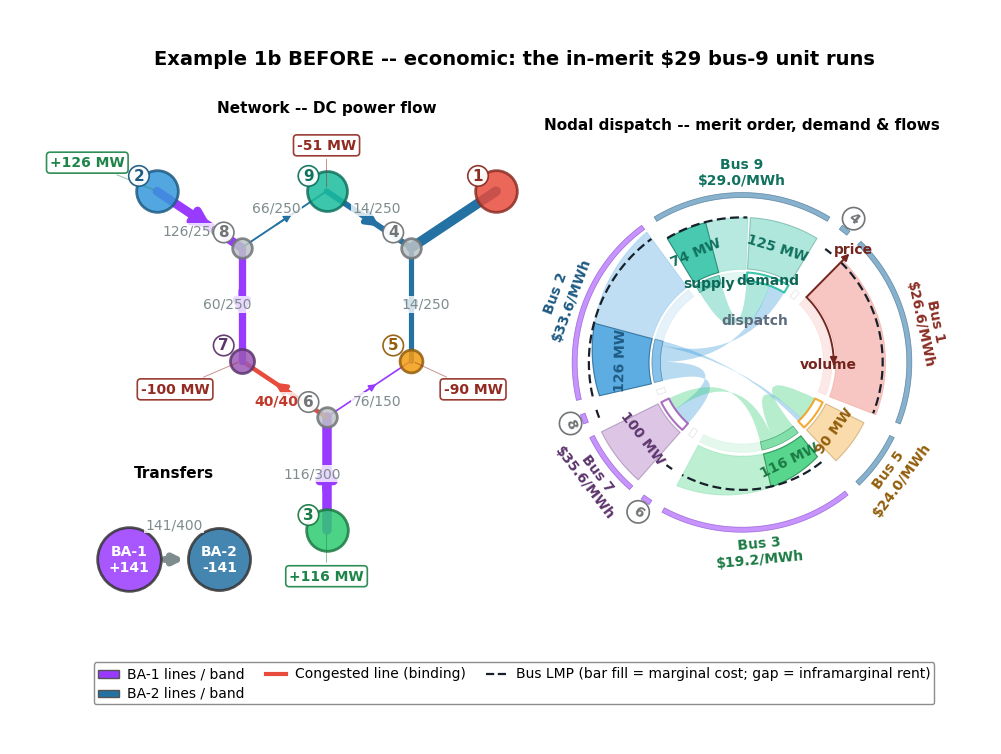

before: bus-9 unit 74 MW (in merit), bus-1 unit 0 MW;  LMP bus 1 / 9 = 26.59 / 29.00

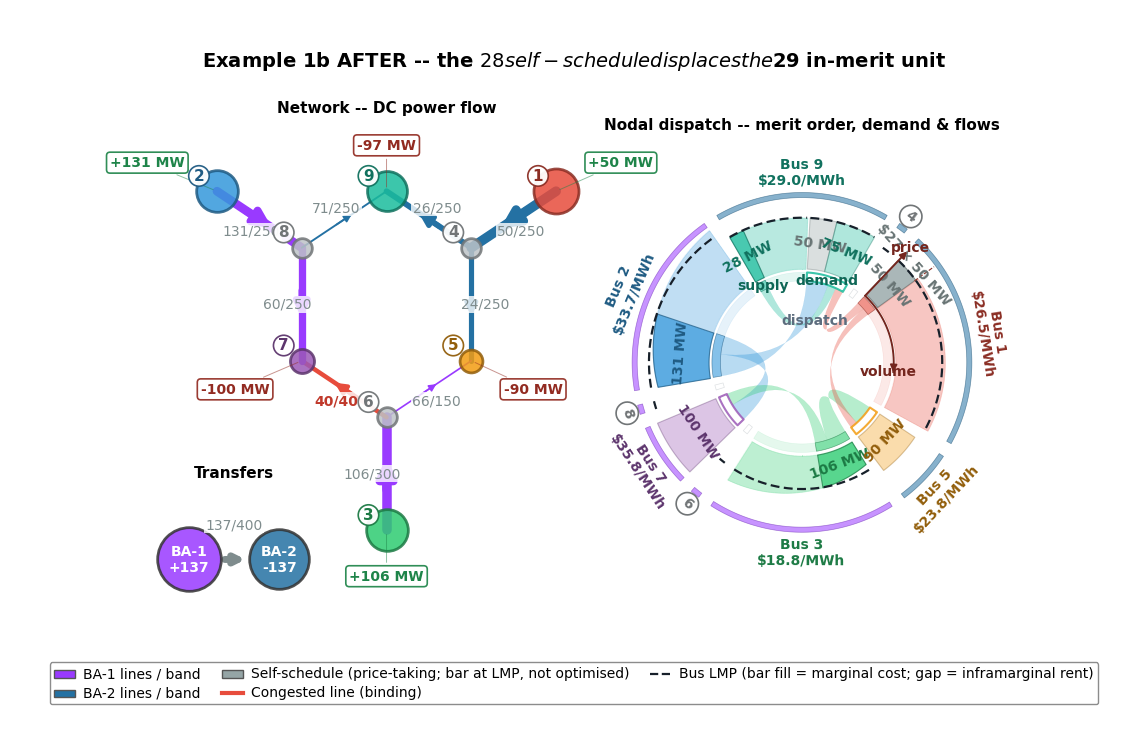


Money-flow ledger -- the self-schedule cannibalises BA-2's own in-merit bus-9 unit:

Economic  Self-schedule  Change  effect
Payments           Consumer payment -- BA-1 (host)                       3560.9         3584.1    23.3        
                   Consumer payment -- BA-2                              5783.2         5767.3   -15.9        
                   Consumer payment -- TOTAL                             9344.0         9351.4     7.4        
                   Gen payment -- BA-1 fleet                             6428.0         6418.0   -10.0        
                   Gen payment -- BA-2 self-scheduler (bus 1, $28)          0.0         1325.2  1325.2        
                   Gen payment -- BA-2 in-merit unit (bus 9, $29)        2143.6          808.6 -1335.1        
                   Gen payment -- TOTAL                                  8571.7         8551.8   -19.8        
                   Production cost (fuel)                                8107.6         8180.3    72.7        
                   Generator profit (pay - cost)                          464.1          371.6   -92.5        
Self-scheduler     Revenue from generating                                  0.0         1325.2  1325.2        
                   Production cost                                          0.0         1400.0  1400.0        
                   Position before congestion revenue                      -0.0          -74.8   -74.8        
Congestion revenue R = consumer pay - gen pay                             772.4          799.6    27.2        
                   CRA -> self-scheduler (S x dLambda)                      0.0          124.8   124.8        
                   CRA -> host BA-1 consumers (residual)                  772.4          674.8   -97.6        
Net position       Consumers BA-1 (host) -- outlay                       2788.5         2909.3   120.9   worse
                   Consumers BA-2 -- outlay                              5783.2         5767.3   -15.9  better
                   Generators BA-1 fleet -- inflow                        464.1          446.4   -17.7   worse
                   Generators BA-2 self-scheduler (bus 1, $28) -- ...      -0.0           50.0    50.0  better
                   Generators BA-2 in-merit unit (bus 9, $29) -- i...      -0.0           -0.0     0.0      --
                   System (= production cost)                            8107.6         8180.3    72.7   worse

  BA-2's in-merit bus-9 unit is backed down 74 -> 28 MW (46 MW displaced) so the $28 bus-1 unit can

  self-schedule and collect the $125 congestion right; system production cost still rises.

In [11]:
# === Example 1b (Harvey Ex 3): the schedule displaces BA-2's own in-merit bus-9 unit ===
C1_3, C9_3 = 28.0, 29.0
FLEET3 = {'gen_slack_0': {'bus': '1', 'cost': C1_3, 'p_nom': 300.0},
          'gen_9':       {'bus': '9', 'cost': C9_3, 'p_nom': 150.0},
          'gen_0':       {'bus': '2', 'cost': 35.0, 'p_nom': 300.0},
          'gen_1':       {'bus': '3', 'cost': 20.0, 'p_nom': 300.0}}
CUR3 = {'gen_slack_0': (C1_3, 0.0), 'gen_9': (C9_3, 0.0),
        'gen_0': CURVES['gen_0'], 'gen_1': CURVES['gen_1']}
GBUS3 = {g: s['bus'] for g, s in FLEET3.items()}          # gen -> bus (adds gen_9)
b3 = clear_ss(CUR3, fleet=FLEET3)                          # BEFORE: bus-9 unit in merit
s3 = clear_ss(CUR3, fleet=FLEET3, loads=LOADS_SS, exo=SS)  # AFTER: bus-1 forced on

ba_figure(CUR3, b3, 'Example 1b BEFORE -- economic: the in-merit $29 bus-9 unit runs',
          fleet=FLEET3)
print(f"before: bus-9 unit {b3.dispatch.get('gen_9', 0.0):.0f} MW (in merit), bus-1 unit "
      f"{b3.gen_by_bus.get('1', 0.0):.0f} MW;  LMP bus 1 / 9 = {b3.lmp['1']:.2f} / {b3.lmp['9']:.2f}")
ba_figure(CUR3, s3, 'Example 1b AFTER -- the $28 self-schedule displaces the $29 in-merit unit',
          ss_pair=(SRC, SNK, S_SS), loads=LOADS_SS, fleet=FLEET3)

# The same money-flow ledger, with BA-2's two units split so the cannibalisation is visible.
_gap3 = s3.lmp[SNK] - s3.lmp[SRC]
led1b = flow_ledger(b3, s3, CUR3, GBUS3, 'BA-1',
                    ss_spec=dict(bus=SRC, cost=C1_3, S=S_SS, group='BA-2 self-scheduler (bus 1, $28)'),
                    gen_groups=[('BA-1 fleet', ['gen_0', 'gen_1']),
                                ('BA-2 self-scheduler (bus 1, $28)', ['gen_slack_0']),
                                ('BA-2 in-merit unit (bus 9, $29)', ['gen_9'])],
                    cra=(0.0, _gap3 * S_SS))
print('\nMoney-flow ledger -- the self-schedule cannibalises BA-2\'s own in-merit bus-9 unit:')
display(led1b)
_disp = b3.dispatch.get('gen_9', 0.0) - s3.dispatch.get('gen_9', 0.0)
print(f"  BA-2's in-merit bus-9 unit is backed down {b3.dispatch.get('gen_9',0.0):.0f} -> "
      f"{s3.dispatch.get('gen_9',0.0):.0f} MW ({_disp:.0f} MW displaced) so the ${C1_3:.0f} bus-1 unit can")
print(f"  self-schedule and collect the ${_gap3*S_SS:.0f} congestion right; system production cost still rises.")


**Read it.** Same ledger, sharper distortion. The **Self-scheduler** block shows the \$28 bus-1 unit again under water on energy — a **position before congestion revenue of −\$75/h** — rescued only by its \$125 congestion right. What pays for it this time is BA-2's *own* in-merit \$29 bus-9 unit: its generator payment collapses \$2,144→\$809 as it is backed down 74→28 MW to free the schedule. So a schedule-keyed rebate makes it rational to **shut down genuinely economic generation** — and it costs more than Example 1: production cost rises **\$73/h** (the displaced megawatts loop harder onto `line_4`), and because the extra flow lifts BA-1's prices, the **host BA-1 consumers are worse off by \$121/h**. The rule pays a loss-making schedule to cannibalise a profitable one, and the host foots the bill.


## 4. Example 2 — paying congestion out without collecting it (after Harvey)

Start from the market's own, **two-sided** treatment. Set BA-2's bus-1 unit **in merit** (\$20/MWh, Harvey's economic baseline), so it genuinely serves bus 9 and loads `line_4` — real, economic congestion, a positive 1→9 price gap.
A **counterflow** schedule — a resource at bus 9 serving load at bus 1, *against* the prevailing direction — is a price-taker like any other: paid $\lambda_9$ where it injects, paying $\lambda_1$ where it withdraws, net $(\lambda_9-\lambda_1)$ per megawatt.
That payment tracks the production-cost saving the counterflow creates, so **no special settlement is needed** (Harvey's Example 4): prevailing schedules pay the congestion they cause, counterflow is paid the congestion it relieves, and the line's rent pool balances.

The concern is a **one-sided** rule: firm-rights schedules in the prevailing direction have their congestion charge **rebated** (nothing is collected from them), while counterflow keeps its market payment.
Harvey states the asymmetry directly — *"the transmission schedule from B to A was paid the difference in prices, while the transmission schedule from A to B was not charged"* — and its consequence: the host collects congestion rent only on the **net** flows over its constraint, *"which would not be enough to pay the congestion charges of the firm transmission customers."*
On his 4-bus example the net-flow collections fall short outright; on this network the line collects more rent, so the same one-sided arithmetic shows up as the pool **draining by the full rebate** — every other claim on the collected congestion revenue shrinks dollar-for-dollar, and nothing was collected from the schedules that caused the flows.
The cells below price the baseline, the counterflow, and then the one-sided ledger.


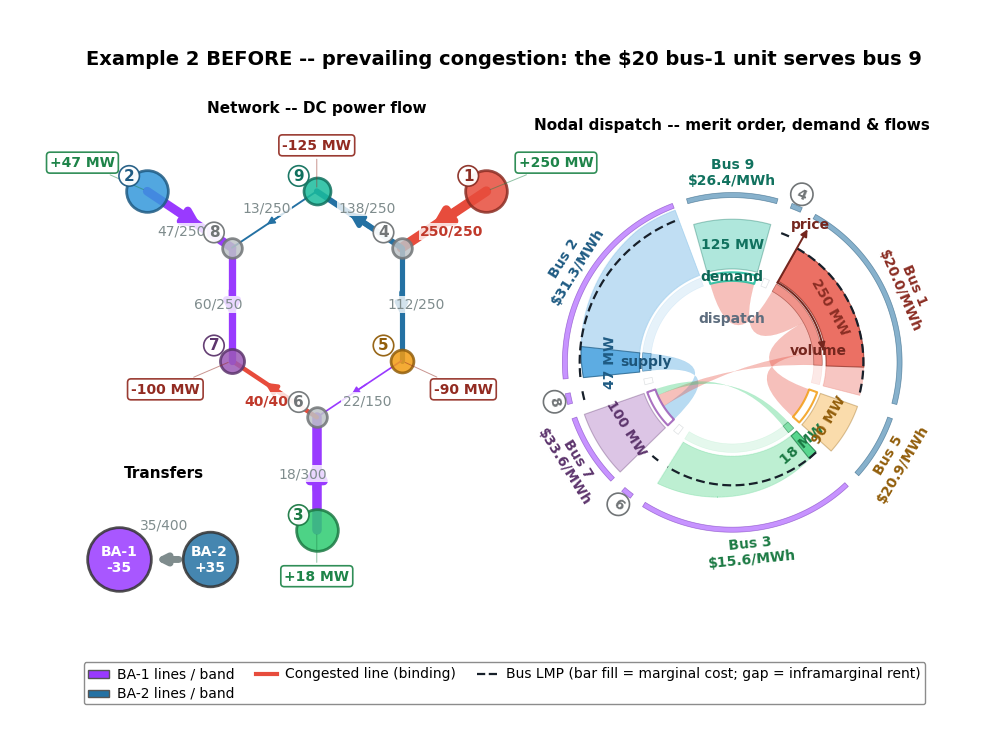

bus-1 unit 250 MW (IN merit);  line_4 40/40 binds;  LMP bus 1 = 20.00, bus 9 = 26.36  (gap $6.36)

In [12]:
# BEFORE -- prevailing economic congestion: the in-merit $20 bus-1 unit loads line_4.
# (Caps lifted to 300 MW so no unit is capacity-bound -- Harvey's clean baseline prices.)
C1_4 = 20.0
FLEET4 = {'gen_slack_0': {'bus': '1', 'cost': C1_4, 'p_nom': 300.0},
          'gen_0':       {'bus': '2', 'cost': 35.0, 'p_nom': 300.0},
          'gen_1':       {'bus': '3', 'cost': 20.0, 'p_nom': 300.0}}
CUR4 = flat1_curves(C1_4)
b4 = clear_ss(CUR4, fleet=FLEET4)
ba_figure(CUR4, b4, 'Example 2 BEFORE -- prevailing congestion: the $20 bus-1 unit serves bus 9',
          fleet=FLEET4)
print(f"bus-1 unit {b4.gen_by_bus.get('1', 0.0):.0f} MW (IN merit);  line_4 "
      f"{b4.flow_own['line_4']:.0f}/40 binds;  LMP bus 1 = {b4.lmp['1']:.2f}, "
      f"bus 9 = {b4.lmp['9']:.2f}  (gap ${b4.lmp['9'] - b4.lmp['1']:.2f})")


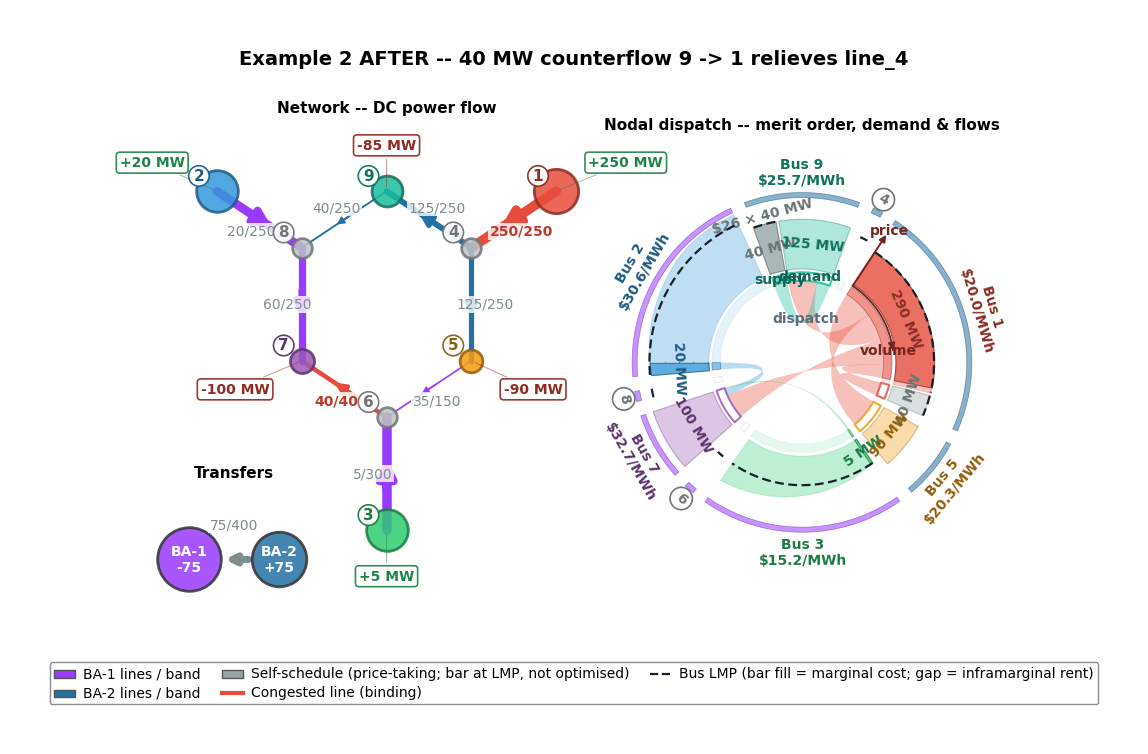

The market pays the counterflow the price difference, which tracks the saving it creates:

,line_4 flow,LMP bus 1,LMP bus 9,counterflow paid (L9-L1) x MW ($/h),system prod-cost saving ($/h)
counterflow 9->1 (MW),,,,,
0.0,40.0,20.0,26.36,0.0,0.0
20.0,40.0,20.0,26.03,121.0,124.0
40.0,40.0,20.0,25.69,228.0,241.0


In [13]:
# AFTER -- a 40 MW counterflow schedule bus 9 -> bus 1, priced by the market alone.
CF = 40.0
r4 = clear_ss(CUR4, fleet=FLEET4, exo={'9': +CF, '1': -CF})
ba_figure(CUR4, r4, f'Example 2 AFTER -- {CF:.0f} MW counterflow 9 -> 1 relieves line_4',
          ss_pair=('9', '1', CF), fleet=FLEET4)
rows = []
for X in [0.0, 20.0, CF]:
    r = b4 if X == 0 else clear_ss(CUR4, fleet=FLEET4, exo={'9': +X, '1': -X})
    rows.append({'counterflow 9->1 (MW)': X, 'line_4 flow': round(r.flow_own['line_4'], 1),
                 'LMP bus 1': round(r.lmp['1'], 2), 'LMP bus 9': round(r.lmp['9'], 2),
                 'counterflow paid (L9-L1) x MW ($/h)': round((r.lmp['9'] - r.lmp['1']) * X, 0),
                 'system prod-cost saving ($/h)': round(_pc_cur(b4, CUR4) - _pc_cur(r, CUR4), 0)})
cf_tbl = pd.DataFrame(rows).set_index('counterflow 9->1 (MW)')
print('The market pays the counterflow the price difference, which tracks the saving it creates:')
display(cf_tbl)


In [14]:
# The ONE-SIDED rule: rebate the prevailing firm schedules, collect nothing from them.
# BA-2's whole self-supply rides on firm rights -- both paths from its bus-1 unit
# (1->9 at 125 MW and 1->5 at 90 MW; "all firm point-to-point flows and flows using
# firm network service"). The counterflow is the CF MW 9->1 schedule above (r4 clear).
FIRM = {('1', '9'): 125.0, ('1', '5'): 90.0}    # the prevailing firm book (source, sink): MW
gaps = {p: r4.lmp[p[1]] - r4.lmp[p[0]] for p in FIRM}
R4 = sum(abs(r4.line_dual[l]) * abs(r4.flow_own[l]) for l in ptD.lines)   # pool collections
charge = sum(max(gaps[p], 0.0) * mw for p, mw in FIRM.items())  # the firm book's congestion charges
cfpay = (r4.lmp['9'] - r4.lmp['1']) * CF                        # counterflow's market payment

onesided = pd.DataFrame({
    'two-sided (market settlement)': {
        'pool collects: congestion rent R ($/h)': round(R4, 0),
        'prevailing firm book pays its charges ($/h)': round(-charge, 0),
        'counterflow 9->1 is paid ($/h)': round(+cfpay, 0),
        'rebate paid back to the firm book ($/h)': 0.0,
        'pool after the rule ($/h)': round(R4, 0)},
    "one-sided rule (pay, don't collect)": {
        'pool collects: congestion rent R ($/h)': round(R4, 0),
        'prevailing firm book pays its charges ($/h)': round(-charge, 0),
        'counterflow 9->1 is paid ($/h)': round(+cfpay, 0),
        'rebate paid back to the firm book ($/h)': round(-charge, 0),
        'pool after the rule ($/h)': round(R4 - charge, 0)}})
print('The rent pool under the two treatments (firm book '
      + ', '.join(f'{a}->{b} {mw:.0f} MW' for (a, b), mw in FIRM.items())
      + f'; counterflow {CF:.0f} MW):')
display(onesided)
short = charge - R4
if short > 0:
    print(f'  ONE-SIDED: the pool collects ${R4:,.0f}/h on the line but hands ${charge:,.0f}/h '
          f'back to the firm book -> SHORT ${short:,.0f}/h, borne by the host BA.')
else:
    print(f'  ONE-SIDED: ${charge:,.0f}/h handed back against ${R4:,.0f}/h collected -- every '
          f'other claim on the pool shrinks by the full rebate.')

# The netted variant (Harvey, "Self-Scheduling"): if the counterflow is the same BAA's firm
# transaction, the flow impact is computed on the BAA's NET firm flows -- the rebate shrinks
# to the net book, and the counterflow itself is paid nothing at all.
gap19 = r4.lmp['9'] - r4.lmp['1']
net_reb = charge - gap19 * CF
print(f'\nNetted variant: the 9->1 counterflow nets against the 1->9 book, the rebate falls to '
      f'${net_reb:,.0f}/h,')
print(f'and the counterflow is paid $0 (vs ${cfpay:,.0f}/h at market) -- so the owner of a '
      f'counterflow-capable')
print('resource would rather offer it at a price that keeps it OUT of the dispatch than forfeit')
print('the congestion payments its dispatch would cost the book (Harvey, "Self-Scheduling" slides).')


The rent pool under the two treatments (firm book 1->9 125 MW, 1->5 90 MW; counterflow 40 MW):

,two-sided (market settlement),"one-sided rule (pay, don't collect)"
pool collects: congestion rent R ($/h),1603.0,1603.0
prevailing firm book pays its charges ($/h),-741.0,-741.0
counterflow 9->1 is paid ($/h),228.0,228.0
rebate paid back to the firm book ($/h),0.0,-741.0
pool after the rule ($/h),1603.0,862.0


  ONE-SIDED: $741/h handed back against $1,603/h collected -- every other claim on the pool shrinks by the full rebate.


Netted variant: the 9->1 counterflow nets against the 1->9 book, the rebate falls to $514/h,

and the counterflow is paid $0 (vs $228/h at market) -- so the owner of a counterflow-capable

resource would rather offer it at a price that keeps it OUT of the dispatch than forfeit

the congestion payments its dispatch would cost the book (Harvey, "Self-Scheduling" slides).

**Read it.** The two-sided column is the market doing its job: prevailing schedules pay the congestion they cause, counterflow is paid the congestion it relieves, and the pool keeps the line's rent.
The one-sided column changes only one thing — the prevailing firm schedules' charges are handed back — and the pool immediately pays out more than the constraint collects for those schedules: the difference is funded by the host BA's other claims on the pool, a tax on hosting the constraint.
The netted variant is worse on the other margin: aggregating a BAA's firm flows before settling un-prices the counterflow inside the netting set, so the resource best placed to *relieve* the constraint is the one the rule teaches to stay out of the market.
Harvey's remedy is minimal and two-sided: pay counterflow its market value, charge prevailing flows their market cost, and if a hedge is owed, cap the *negative* credit at zero rather than un-pricing either side — the price difference already values both directions correctly.


## 5. Example 3 — congestion revenue attached to awards, not schedules (after Pope)

Examples 1–2 tested the **start-up rule**: the congestion revenue attaches only to balanced **self-schedules** exercising eligible firm rights.
The proposed near-term enhancement extends it to **cleared, balanced day-ahead market awards** supported by the same rights: offer the resource economically, and whatever **clears** against the entity's own load earns the same rebate $\rho$ of eq. (4) that a self-schedule would.
Harvey flags the same design axis from the other side: when the rents are contingent on the resource being *dispatched*, the entitlement rides on the award — and an owner can protect or manufacture the award through its offers.

Write $X$ for the balanced megawatts that **clear** when the resource is offered economically ($X=\min(\text{cleared output},S)$). The entity's cost of meeting its $S$ MW of sink load, by strategy and rule:

$$\underset{\text{don't offer, buy}}{\lambda_{\mathrm{sink}}\,S},\qquad
\underset{\text{self-schedule (either rule)}}{c\,S},\qquad
\underset{\text{offer — start-up rule}}{c\,X+(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}})\,X+\lambda_{\mathrm{sink}}\,(S-X)},\qquad
\underset{\text{offer — cleared rule}}{c\,X+\lambda_{\mathrm{sink}}\,(S-X)}.\qquad(6)$$

*In words.* The resource's cost of meeting its $S$ MW of sink load, by strategy: buy at the market, $\lambda_{\mathrm{sink}}S$; self-schedule under either rule, its own fuel cost $cS$; offer economically under the start-up rule, fuel cost on the cleared MW $X$ plus that block's congestion charge plus the market price on the uncleared remainder; offer economically under the cleared rule, the same but with no congestion charge on the cleared block.

The saving from self-scheduling instead of offering, by rule:

$$\Delta^{\text{start-up}}=\underbrace{(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}})\,X}_{\text{cleared, yet unhedged}}\;+\;\underbrace{(\lambda_{\mathrm{sink}}-c)\,(S-X)}_{\text{backed-down block}},
\qquad\qquad
\Delta^{\text{cleared}}=(\lambda_{\mathrm{sink}}-c)\,(S-X).\qquad(7)$$

*In words.* Under the start-up rule **every** balanced OATT position prefers to self-schedule whenever the path congests — economic bidding forfeits the hedge (use-it-or-lose-it).
The cleared rule deletes the first term: an in-merit resource ($X=S$) keeps its hedge while bidding economically — a genuine improvement.
What survives is the second term: whenever the market would dispatch the resource **down** ($X<S$) and its cost still sits below the sink price, forcing the full schedule on still pays — the same perverse zone as Example 1, now confined to the dispatched-down case, and widest exactly at times of significant congestion.

> This section follows **Susan L. Pope, *Opinion on California ISO Final Proposal for EDAM Congestion Revenue Allocation*** (Western Energy Markets Governing Body Market Expert memorandum, June 16, 2025), "Near-Term Enhancements," pp. 18–21: extending the allocation to cleared balanced market schedules "might at times reduce the self-scheduling incentive … it would not remove it during times of significant congestion. And it is at times of significant congestion when self-scheduling would lead to the greatest losses in EDAM efficiency." Source: https://www.caiso.com/documents/wem-governing-body-market-expert-opinon-on-extended-day-ahead-market-congestion-revenue-allocation-jun-18-2025.pdf


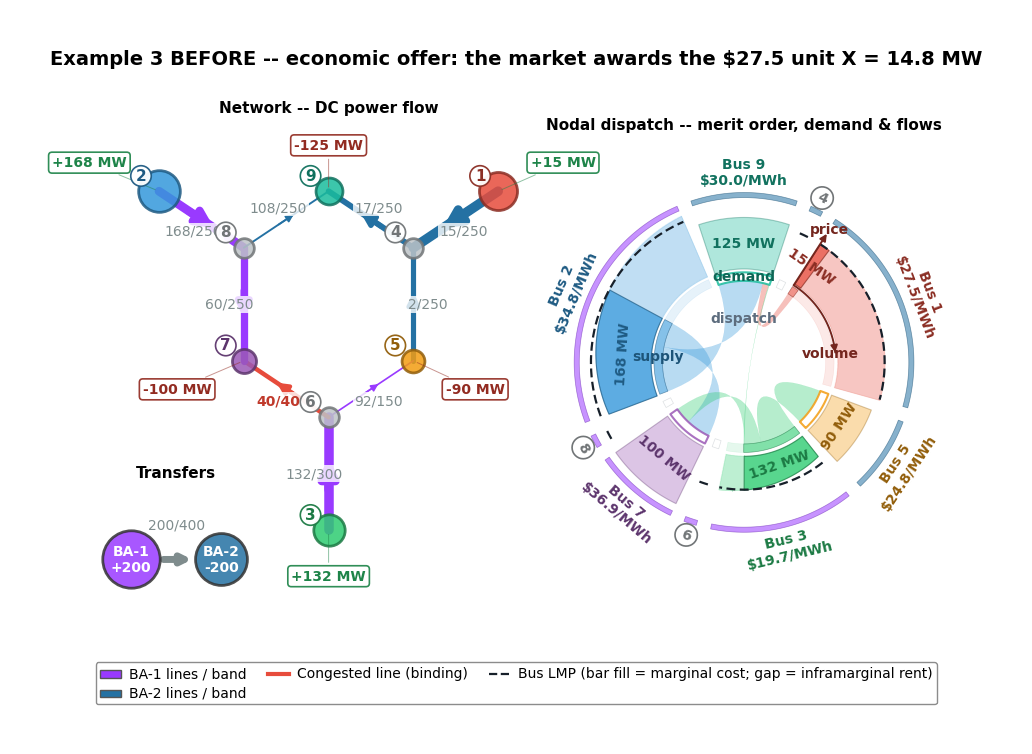

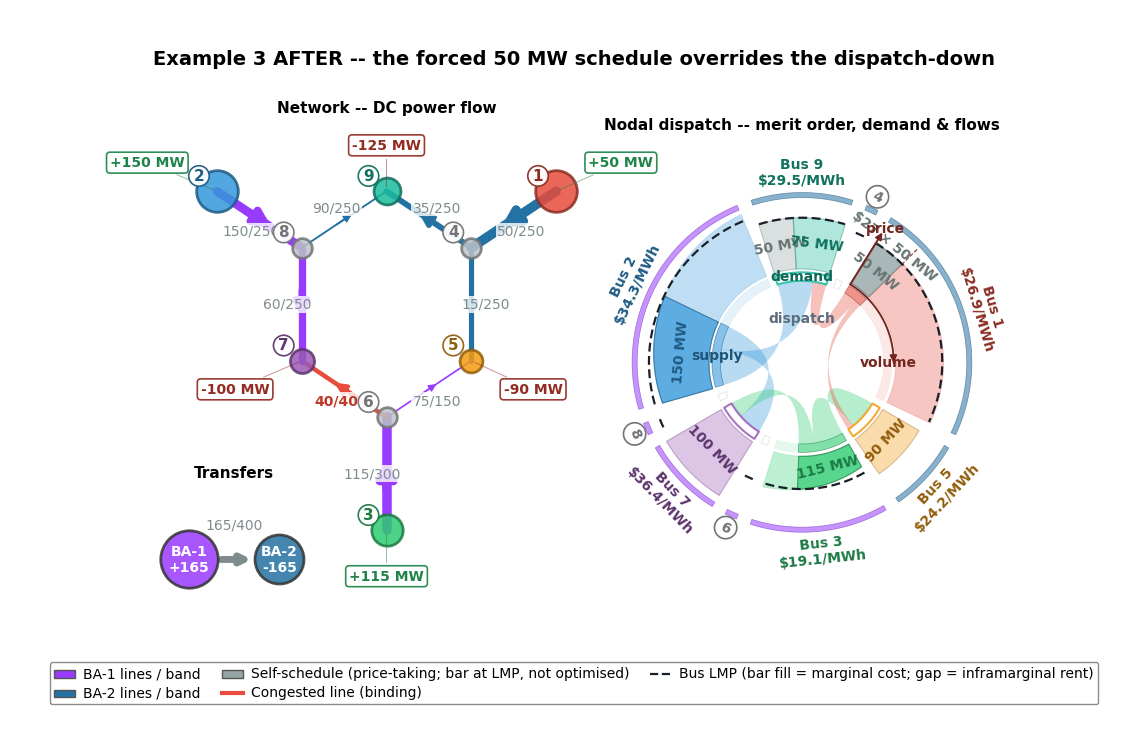

The owner's menu at c = $27.5 (dispatched down: X = 14.8 of 50 MW); net = eq. (6)'s strategy costs:

,offer -- START-UP rule,offer -- CLEARED rule (award-keyed),forced self-schedule (either rule)
MW cleared (award X),14.8,14.8,0.0
MW self-scheduled,0.0,0.0,50.0
cost to produce ($/h),-408.0,-408.0,-1375.0
revenue from generating ($/h),408.0,408.0,1347.0
load buys its 50 MW at bus 9 ($/h),-1501.0,-1501.0,-1474.0
revenue from congestion -- CRA ($/h),0.0,37.0,127.0
net cost of meeting the 50 MW ($/h),-1501.0,-1464.0,-1375.0



Money-flow ledger under the CLEARED rule -- economic offer (award X hedged) vs forcing the full 50 MW:

Economic offer (award X)  Forced self-schedule  Change  effect
Payments           Consumer payment -- BA-1 (host)                                  3691.5                3641.4   -50.1        
                   Consumer payment -- BA-2                                         5981.9                5861.4  -120.5        
                   Consumer payment -- TOTAL                                        9673.4                9502.8  -170.7        
                   Gen payment -- BA-1 fleet                                        8459.5                7344.4 -1115.1        
                   Gen payment -- BA-2 offer/self-schedule                           407.7                1346.9   939.2        
                   Gen payment -- TOTAL                                             8867.2                8691.3  -175.9        
                   Production cost (fuel)                                           8151.9                8161.8     9.9        
                   Generator profit (pay - cost)                                     715.3                 529.5  -185.8        
Self-scheduler     Revenue from generating                                           407.7                1346.9   939.2        
                   Production cost                                                   407.7                1375.0   967.3        
                   Position before congestion revenue                                 -0.0                 -28.1   -28.1        
Congestion revenue R = consumer pay - gen pay                                        806.2                 811.5     5.3        
                   CRA -> self-scheduler (S x dLambda)                                37.3                 126.6    89.3        
                   CRA -> host BA-1 consumers (residual)                             768.9                 684.9   -84.1        
Net position       Consumers BA-1 (host) -- outlay                                  2922.6                2956.5    34.0   worse
                   Consumers BA-2 -- outlay                                         5981.9                5861.4  -120.5  better
                   Generators BA-1 fleet -- inflow                                   715.3                 557.6  -157.7   worse
                   Generators BA-2 offer/self-schedule -- inflow                      37.3                  98.5    61.2  better
                   System (= production cost)                                       8151.9                8161.8     9.9   worse

  Even under the cleared rule the schedule extracts more: the award hedges only X = 14.8 MW, so forcing all 50 on captures the congestion right on the backed-down (S-X) block too --

  the residual incentive of eq. (7), and it lands on the host BA-1 consumers exactly as in Example 1.

In [15]:
# === Example 3 before/after: the dispatched-down case (c = $27.5), the CLEARED rule ===
# Offered economically the market awards the unit only X of its 50 MW backing; under the
# CLEARED rule the congestion revenue attaches to that AWARD (rebated in BOTH columns).
# Forcing the full schedule on still pays for the backed-down remainder -- and the award
# itself is offer-sensitive.
C3 = 27.5
CURp = flat1_curves(C3)
ex3_base = clear_ss(CURp)                                # BEFORE: economic offer, award X
ex3_ss   = clear_ss(CURp, loads=LOADS_SS, exo=SS)        # AFTER: forced 50 MW schedule
X3 = min(ex3_base.gen_by_bus.get(SRC, 0.0), S_SS)
l1b, l9b = ex3_base.lmp[SRC], ex3_base.lmp[SNK]
l1s, l9s = ex3_ss.lmp[SRC], ex3_ss.lmp[SNK]

ba_figure(CURp, ex3_base,
          f'Example 3 BEFORE -- economic offer: the market awards the ${C3:.1f} unit X = {X3:.1f} MW')
ba_figure(CURp, ex3_ss,
          f'Example 3 AFTER -- the forced {S_SS:.0f} MW schedule overrides the dispatch-down',
          ss_pair=(SRC, SNK, S_SS), loads=LOADS_SS)

# The owner's strategy menu (eq. 6): cost of meeting the 50 MW, by strategy and rule.
mot3 = pd.DataFrame({
    'offer -- START-UP rule': {
        'MW cleared (award X)': round(X3, 1), 'MW self-scheduled': 0.0,
        'cost to produce ($/h)': round(-C3 * X3, 0),
        'revenue from generating ($/h)': round(l1b * X3, 0),
        'load buys its 50 MW at bus 9 ($/h)': round(-l9b * S_SS, 0),
        'revenue from congestion -- CRA ($/h)': 0.0,
        'net cost of meeting the 50 MW ($/h)': round((l1b - C3) * X3 - l9b * S_SS, 0)},
    'offer -- CLEARED rule (award-keyed)': {
        'MW cleared (award X)': round(X3, 1), 'MW self-scheduled': 0.0,
        'cost to produce ($/h)': round(-C3 * X3, 0),
        'revenue from generating ($/h)': round(l1b * X3, 0),
        'load buys its 50 MW at bus 9 ($/h)': round(-l9b * S_SS, 0),
        'revenue from congestion -- CRA ($/h)': round((l9b - l1b) * X3, 0),
        'net cost of meeting the 50 MW ($/h)': round((l1b - C3) * X3 + (l9b - l1b) * X3 - l9b * S_SS, 0)},
    'forced self-schedule (either rule)': {
        'MW cleared (award X)': 0.0, 'MW self-scheduled': round(S_SS, 1),
        'cost to produce ($/h)': round(-C3 * S_SS, 0),
        'revenue from generating ($/h)': round(l1s * S_SS, 0),
        'load buys its 50 MW at bus 9 ($/h)': round(-l9s * S_SS, 0),
        'revenue from congestion -- CRA ($/h)': round((l9s - l1s) * S_SS, 0),
        'net cost of meeting the 50 MW ($/h)': round((l1s - C3) * S_SS + (l9s - l1s) * S_SS - l9s * S_SS, 0)}})
print(f"The owner's menu at c = ${C3:.1f} (dispatched down: X = {X3:.1f} of {S_SS:.0f} MW); "
      "net = eq. (6)'s strategy costs:")
display(mot3)

# The money-flow ledger, CLEARED rule: economic offer (award X hedged) vs forced schedule.
# Under the cleared rule the award X earns the congestion right in the ECONOMIC column too,
# so cra = ((L9-L1)*X economic, (L9-L1)*S self-schedule).
led3 = flow_ledger(ex3_base, ex3_ss, CURp, GBUS, 'BA-1',
                   ss_spec=dict(bus=SRC, cost=C3, S=S_SS, group='BA-2 offer/self-schedule'),
                   gen_groups=[('BA-1 fleet', ['gen_0', 'gen_1']),
                               ('BA-2 offer/self-schedule', ['gen_slack_0'])],
                   cra=((l9b - l1b) * X3, (l9s - l1s) * S_SS),
                   cols=('Economic offer (award X)', 'Forced self-schedule'))
print('\nMoney-flow ledger under the CLEARED rule -- economic offer (award X hedged) vs '
      'forcing the full 50 MW:')
display(led3)
print(f'  Even under the cleared rule the schedule extracts more: the award hedges only X = '
      f'{X3:.1f} MW, so forcing all {S_SS:.0f} on captures the congestion right on the '
      f'backed-down (S-X) block too --')
print('  the residual incentive of eq. (7), and it lands on the host BA-1 consumers exactly as '
      'in Example 1.')


In [16]:
# === The two rules, four resource costs: in-merit / dispatched-down / out-of-merit zone / dear ===
# Same balanced 50 MW bus-1 -> bus-9 position as Example 1 (BA-2's own load, firm 1->9 right),
# BA-2's bus-1 unit at a single FLAT marginal cost c. For each c, clear the joint dispatch twice --
# WITHOUT the schedule (the economic-offer clear: the market picks the unit's output X) and WITH the
# forced 50 MW self-schedule -- and price the strategy menu of eq. (6) under each rule.
def _c1_clear(c1, rating=40.0):
    CUR = {'gen_slack_0': (c1, 0.0), 'gen_0': (30.0, 0.0284), 'gen_1': (15.0, 0.036)}
    _net = build_network({'line_4': rating}); _pt = compute_ptdf(_net, slack_bus='1')
    _ifcs = {D_IFC: float(sum(_pt.s_nom[_pt.line_idx[l]] for l in ties))}
    base = solve_engine_transfers(_pt, make_engine('UNIFIED', buses=_pt.buses), BA_DEFS, _ifcs,
                                  curves=CUR, shed_price=SHED_PRICE)
    ssres = solve_engine_transfers(_pt, make_engine('UNIFIED', buses=_pt.buses, loads=LOADS_SS),
                                   BA_DEFS, _ifcs, curves=CUR, exo=SS, shed_price=SHED_PRICE)
    _pc = lambda r: sum(CUR[g][0]*r.dispatch.get(g, 0.0) + 0.5*CUR[g][1]*r.dispatch.get(g, 0.0)**2
                        for g in CUR if g in r.dispatch)
    return base, ssres, _pc

def _menu(c1, rating=40.0):
    base, ssres, _pc = _c1_clear(c1, rating)
    l1, l9 = base.lmp['1'], base.lmp['9']
    X = min(base.gen_by_bus.get('1', 0.0), S_SS)
    buy      = l9*S_SS
    offer_p1 = c1*X + (l9 - l1)*X + l9*(S_SS - X)     # start-up rule: cleared pair unhedged
    offer_c1 = c1*X + l9*(S_SS - X)                   # cleared rule: cleared pair rebated
    self_c   = c1*S_SS                                # either rule: hedged, own fuel
    dw       = (_pc(ssres) + c1*S_SS) - _pc(base)     # system production-cost change if forced on
    best = lambda offer: 'self-schedule' if self_c < min(offer, buy) - 1e-6 else 'offer economically'
    return {'cleared X of the 50 MW (economic offer)': round(X, 1),
            'LMP bus 1 / bus 9 (economic clear)': f"{l1:.2f} / {l9:.2f}",
            'buy at bus 9 ($/h)':                      round(buy, 0),
            'offer econ -- START-UP rule ($/h)':       round(offer_p1, 0),
            'offer econ -- CLEARED rule ($/h)':        round(offer_c1, 0),
            'self-schedule = own fuel ($/h)':          round(self_c, 0),
            'best -- START-UP rule':                   best(offer_p1),
            'best -- CLEARED rule':                    best(offer_c1),
            'system prod-cost change if forced on':    round(dw, 0)}

CASES = [(25.0, '$25 (in-merit)'), (27.5, '$27.5 (dispatched down)'),
         (29.0, '$29 (out-of-merit zone)'), (32.0, '$32 (dear)')]
rule_tbl = pd.DataFrame({lab: _menu(c) for c, lab in CASES})
print('Meeting the 50 MW under the start-up rule (rebate self-schedules only) vs the cleared rule (rebate cleared balanced schedules):')
display(rule_tbl)
print('  START-UP rule: self-scheduling wins at every cost below the bus-9 price -- even the in-merit $25 unit')
print('  (economic bidding forfeits the hedge, so it gives up the price gap x 50). The CLEARED rule fixes the')
print('  in-merit case -- the cleared pair keeps its hedge, so there is no reason to self-schedule -- but the')
print('  $27.5 unit the market dispatches DOWN and the $29 unit it leaves OFF both still force their schedules on.')


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Meeting the 50 MW under the start-up rule (rebate self-schedules only) vs the cleared rule (rebate cleared balanced schedules):

,$25 (in-merit),$27.5 (dispatched down),$29 (out-of-merit zone),$32 (dear)
cleared X of the 50 MW (economic offer),50.0,14.8,0.0,0.0
LMP bus 1 / bus 9 (economic clear),25.00 / 27.59,27.50 / 30.02,27.74 / 30.25,27.74 / 30.25
buy at bus 9 ($/h),1379.0,1501.0,1512.0,1512.0
offer econ -- START-UP rule ($/h),1379.0,1501.0,1512.0,1512.0
offer econ -- CLEARED rule ($/h),1250.0,1464.0,1512.0,1512.0
self-schedule = own fuel ($/h),1250.0,1375.0,1450.0,1600.0
best -- START-UP rule,self-schedule,self-schedule,self-schedule,offer economically
best -- CLEARED rule,offer economically,self-schedule,self-schedule,offer economically
system prod-cost change if forced on,-0.0,10.0,83.0,233.0


  START-UP rule: self-scheduling wins at every cost below the bus-9 price -- even the in-merit $25 unit

  (economic bidding forfeits the hedge, so it gives up the price gap x 50). The CLEARED rule fixes the

  in-merit case -- the cleared pair keeps its hedge, so there is no reason to self-schedule -- but the

  $27.5 unit the market dispatches DOWN and the $29 unit it leaves OFF both still force their schedules on.

In [17]:
# === "During times of significant congestion": sweep the neighbouring constraint's severity ===
# Hold the zone resource at c = $29 and sweep the line_4 rating. The zone (lambda_1, lambda_9) exists
# only while the constraint binds, and its width -- the parallel-flow congestion charge on the 1->9
# path -- grows with the constraint's shadow price. (On this small network the redispatch pair that
# holds line_4 caps the shadow-price growth, so the gap widens modestly; the flip at the unconstrained
# rating is the structural point.)
C_ZONE = 29.0
rows = []
for r in [200.0, 63.0, 40.0, 25.0, 14.0]:
    base, ssres, _pc = _c1_clear(C_ZONE, r)
    l1, l9 = base.lmp['1'], base.lmp['9']
    X = min(base.gen_by_bus.get('1', 0.0), S_SS)
    offer_c1 = C_ZONE*X + l9*(S_SS - X)
    self_c = C_ZONE*S_SS
    dw = (_pc(ssres) + C_ZONE*S_SS) - _pc(base)
    rows.append({'line_4 rating (MW)': r,
                 '|mu_4| ($/MWh)': round(abs(base.line_dual.get('line_4', 0.0)), 1),
                 'zone (LMP1, LMP9)': f"({l1:.2f}, {l9:.2f})",
                 'zone width ($/MWh)': round(l9 - l1, 2),
                 '$29 unit in the zone?': 'yes' if l1 + 1e-6 < C_ZONE < l9 - 1e-6 else 'no',
                 'self-sched saving under CLEARED rule ($/h)': round(max(offer_c1 - self_c, 0.0), 0),
                 'forces schedule on?': 'YES' if self_c < offer_c1 - 1e-6 else 'no',
                 'system prod-cost change ($/h)': round(dw, 0)})
sev_tbl = pd.DataFrame(rows).set_index('line_4 rating (MW)')
print('The cleared rule and congestion severity (c = $29, the balanced 50 MW held fixed):')
display(sev_tbl)
print('  Unconstrained (200 MW): no line binds and one price clears the system -> no zone -> nothing to game.')
print('  Constrained: the zone opens, the $29 unit sits inside it at every binding rating, and both the private')
print('  saving and the production-cost damage grow with the shadow price -- the incentive survives exactly when')
print('  self-scheduling is most costly.')


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


...

,|mu_4| ($/MWh),"zone (LMP1, LMP9)",zone width ($/MWh),$29 unit in the zone?,self-sched saving under CLEARED rule ($/h),forces schedule on?,system prod-cost change ($/h)
line_4 rating (MW),,,,,,,
200.0,0.0,"(29.00, 29.00)",0.00,no,0.0,no,0.0
63.0,17.4,"(27.82, 30.00)",2.18,yes,50.0,YES,79.0
40.0,20.1,"(27.74, 30.25)",2.51,yes,62.0,YES,83.0
25.0,21.8,"(27.68, 30.41)",2.73,yes,70.0,YES,86.0
14.0,23.1,"(27.64, 30.53)",2.89,yes,76.0,YES,88.0


  Unconstrained (200 MW): no line binds and one price clears the system -> no zone -> nothing to game.

  Constrained: the zone opens, the $29 unit sits inside it at every binding rating, and both the private

  saving and the production-cost damage grow with the shadow price -- the incentive survives exactly when

  self-scheduling is most costly.

**Read it.** The cleared rule is a real but partial fix, and the two views agree on where it stops.

The **strategy menu** shows the improvement at the in-merit end (the four-cost rule table and severity sweep make it explicit): under the start-up rule even a unit the market would dispatch self-schedules, because bidding economically forfeits the rebate on its cleared position; the cleared rule lets the **award** keep that hedge, so the in-merit incentive vanishes.

The **flow ledger** shows what survives. At \$27.5 the unit is *dispatched down* — the market awards only X = 14.8 of its 50 MW — and the Self-scheduler block reads a **position before congestion revenue of −\$28/h** in either column. The cleared rule hedges the award X, but the backed-down remainder $S-X$ loses coverage, so forcing the full 50 on captures the congestion right on that block too: the self-scheduler's net rises **+\$61/h** over offering economically, and it lands on the **host BA-1 consumers** (+\$34/h) exactly as in Example 1 — the residual incentive of eq. (7). The severity sweep closes it: unconstrained there is no zone and the incentive is gone; at every binding rating the zone persists and the transfer grows with the shadow price, so the residual bites hardest at times of significant congestion.

The durable fix, from both Harvey's and Pope's analyses, is a **fixed financial entitlement** — paid for holding the right, settled at the constraint's shadow price — rather than revenue keyed to self-schedules (Examples 1–2) or to awards (Example 3), so every resource keeps facing the true cost of the congestion it causes.
